# 04. Spatial Hotspot Analysis

본 단계에서는 격자별 교통사고가 공간적으로 집중되어 나타나는지 확인하기 위해  
공간 시각화 및 공간 자기상관 분석을 수행한다.

구체적으로 다음을 확인한다.

1. 격자별 교통사고의 공간 분포 시각화
2. 교통사고의 공간 자기상관 여부 확인 (Moran's I)
3. 사고 hotspot / coldspot 식별 (Getis-Ord Gi*)
4. 사고 집중 지역의 공간적 특성 파악

이 분석을 통해 교통사고가 무작위로 발생하는 것이 아니라
특정 지역에 구조적으로 집중되는 현상임을 검증하고자 한다.

In [1]:
# 기본 라이브러리 및 시각화 기본 설정
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl

from shapely import wkt
sns.set_theme(
    style="whitegrid",
    palette="deep",
    context="notebook",
    font_scale=1.15
)

plt.rcParams["figure.figsize"] = (10, 6)
mpl.rcParams["axes.unicode_minus"] = False

In [4]:
# 데이터 불러오기

data_path = "../outputs/processed/02_train_base_final_features.csv"
df = pd.read_csv(data_path)

print(df.shape)
df.head()

(105032, 28)


,gid,city,geometry,acc_cnt,acc_binary,resident_pop,flow_pop,working_pop,visit_pop,service_pop,...,daycare_count,cctv_count,speedbump_count,blockType_main,landuse_group,is_residential,is_commercial,is_green,is_road,is_public
0,다사581304,경기도 성남시,POLYGON ((127.02677465735422 37.37172194466841...,0,0,0.0,0.000000,0.000000,0.000000,0.0,...,0.0,0.0,0.0,unknown,other,0,0,0,0,0
1,다사581305,경기도 성남시,POLYGON ((127.02676899519032 37.37262330005522...,0,0,0.0,0.031594,0.015572,0.016022,0.0,...,0.0,0.0,0.0,unknown,other,0,0,0,0,0
2,다사581306,경기도 성남시,POLYGON ((127.02676333277432 37.37352465530359...,0,0,0.0,0.000000,0.000000,0.000000,0.0,...,0.0,0.0,0.0,unknown,other,0,0,0,0,0
3,다사582304,경기도 성남시,POLYGON ((127.02790403835982 37.37172645813172...,0,0,0.0,0.022768,0.018269,0.004499,0.0,...,0.0,0.0,0.0,unknown,other,0,0,0,0,0
4,다사582305,경기도 성남시,POLYGON ((127.02789838970781 37.37262781366482...,0,0,0.0,0.031655,0.016485,0.015169,0.0,...,0.0,0.0,0.0,unknown,other,0,0,0,0,0


In [7]:
# geometry 컬럼 상태 확인
print(type(df.loc[0, "geometry"]))
print(df.loc[0, "geometry"])

<class 'shapely.geometry.polygon.Polygon'>
POLYGON ((127.02677465735422 37.37172194466841, 127.02676899519032 37.372623300055224, 127.02789838970781 37.37262781366482, 127.02790403835982 37.37172645813172, 127.02677465735422 37.37172194466841))


In [8]:
# geometry 변환 코드

from shapely import wkt
from shapely.geometry.base import BaseGeometry

def safe_to_geometry(x):
    # 이미 shapely geometry면 그대로 반환
    if isinstance(x, BaseGeometry):
        return x
    # 문자열이면 WKT로 변환
    elif isinstance(x, str):
        return wkt.loads(x)
    else:
        return None

df["geometry"] = df["geometry"].apply(safe_to_geometry)

gdf = gpd.GeoDataFrame(df, geometry="geometry", crs="EPSG:4326")

print(gdf.shape)
print(gdf.crs)
print(gdf.geom_type.value_counts())
gdf.head()

(105032, 28)
EPSG:4326
Polygon    105032
Name: count, dtype: int64


,gid,city,geometry,acc_cnt,acc_binary,resident_pop,flow_pop,working_pop,visit_pop,service_pop,...,daycare_count,cctv_count,speedbump_count,blockType_main,landuse_group,is_residential,is_commercial,is_green,is_road,is_public
0,다사581304,경기도 성남시,"POLYGON ((127.02677 37.37172, 127.02677 37.372...",0,0,0.0,0.000000,0.000000,0.000000,0.0,...,0.0,0.0,0.0,unknown,other,0,0,0,0,0
1,다사581305,경기도 성남시,"POLYGON ((127.02677 37.37262, 127.02676 37.373...",0,0,0.0,0.031594,0.015572,0.016022,0.0,...,0.0,0.0,0.0,unknown,other,0,0,0,0,0
2,다사581306,경기도 성남시,"POLYGON ((127.02676 37.37352, 127.02676 37.374...",0,0,0.0,0.000000,0.000000,0.000000,0.0,...,0.0,0.0,0.0,unknown,other,0,0,0,0,0
3,다사582304,경기도 성남시,"POLYGON ((127.02790 37.37173, 127.02790 37.372...",0,0,0.0,0.022768,0.018269,0.004499,0.0,...,0.0,0.0,0.0,unknown,other,0,0,0,0,0
4,다사582305,경기도 성남시,"POLYGON ((127.02790 37.37263, 127.02789 37.373...",0,0,0.0,0.031655,0.016485,0.015169,0.0,...,0.0,0.0,0.0,unknown,other,0,0,0,0,0


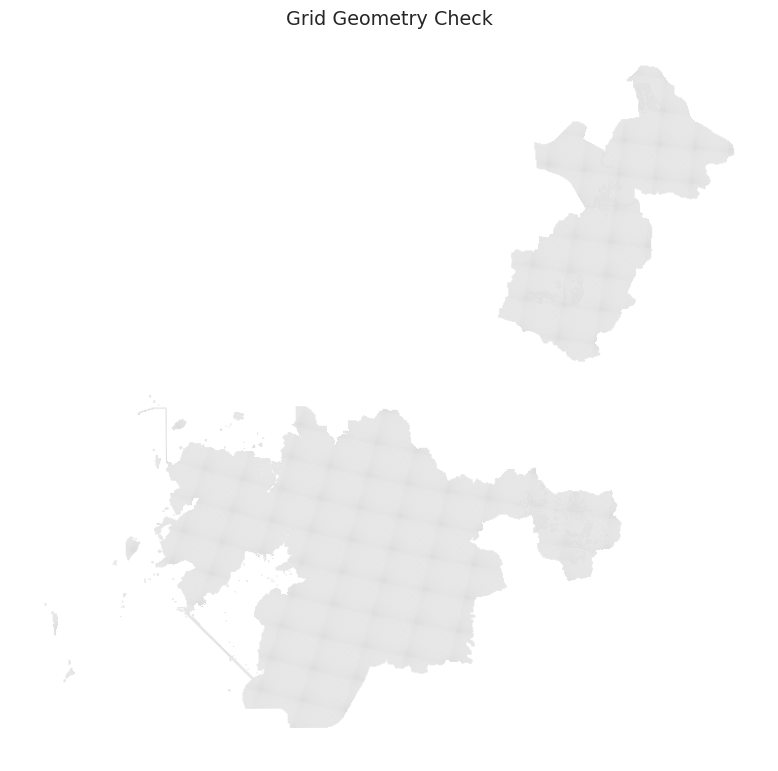

In [9]:
# geometry 변환 지도 체크
fig, ax = plt.subplots(figsize=(8, 8))

gdf.plot(
    ax=ax,
    color="lightgray",
    edgecolor="white",
    linewidth=0.1
)

ax.set_title("Grid Geometry Check")
ax.axis("off")
plt.tight_layout()
plt.show()

In [10]:
# 공간분석 라이브러리 import 가능 여부 확인 -> 불가로 확인
spatial_ok = True

try:
    import libpysal
    from libpysal.weights import Queen, KNN
    from esda.moran import Moran
    from esda.getisord import G_Local
    print("Spatial packages are available.")
except Exception as e:
    spatial_ok = False
    print("Spatial packages are NOT available.")
    print("Error:", e)

Spatial packages are NOT available.
Error: No module named 'libpysal'


## 교통사고의 공간 분포

격자별 교통사고를 지도상에 시각화한 결과, 사고는 도시 전체에 균등하게 분포하지 않고 일부 지역에 상대적으로 집중되는 양상을 보였다.

특히 사고 발생 여부를 기준으로 보더라도 사고 발생 격자가 연속적으로 나타나는 구간이 확인되며, 이는 교통사고가 단순한 개별 사건의 집합이 아니라 특정 공간 구조와 관련되어 나타날 가능성을 시사한다.

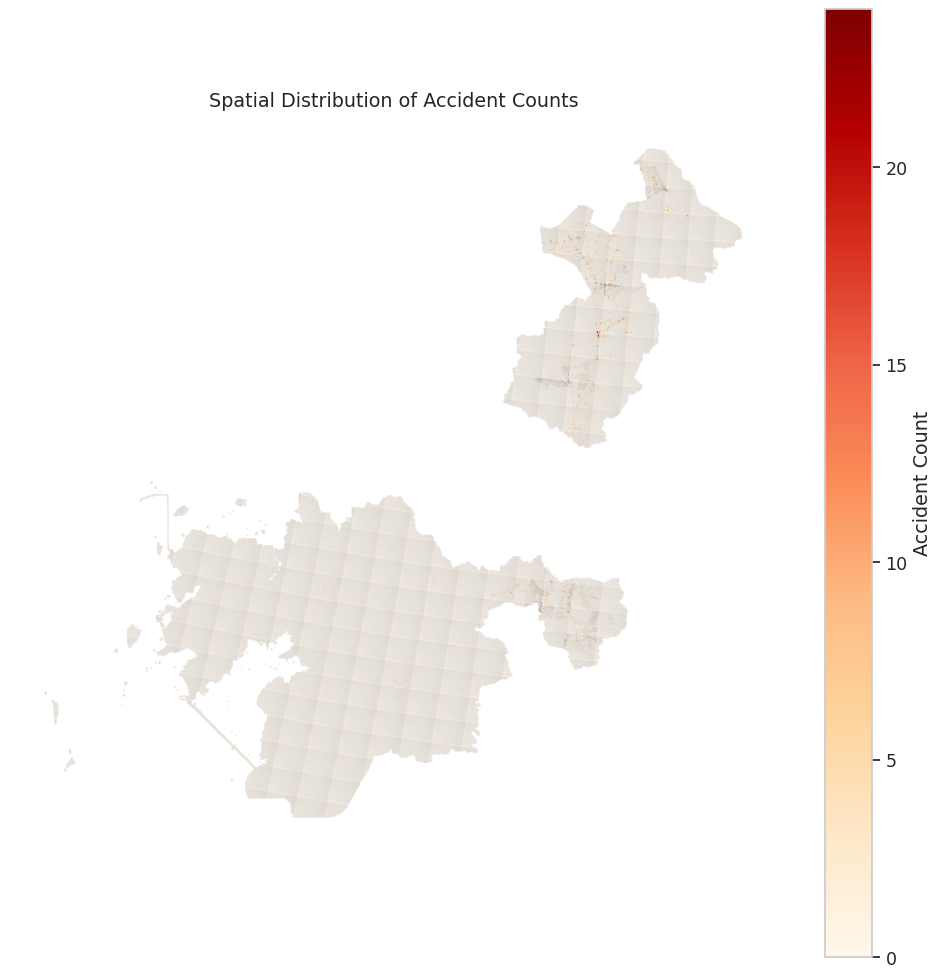

In [11]:
# 1) 사고건수 지도
fig, ax = plt.subplots(figsize=(10, 10))

gdf.plot(
    column="acc_cnt",
    cmap="OrRd",
    linewidth=0.05,
    edgecolor="gray",
    legend=True,
    ax=ax,
    legend_kwds={"label": "Accident Count"}
)

ax.set_title("Spatial Distribution of Accident Counts")
ax.axis("off")
plt.tight_layout()
plt.show()

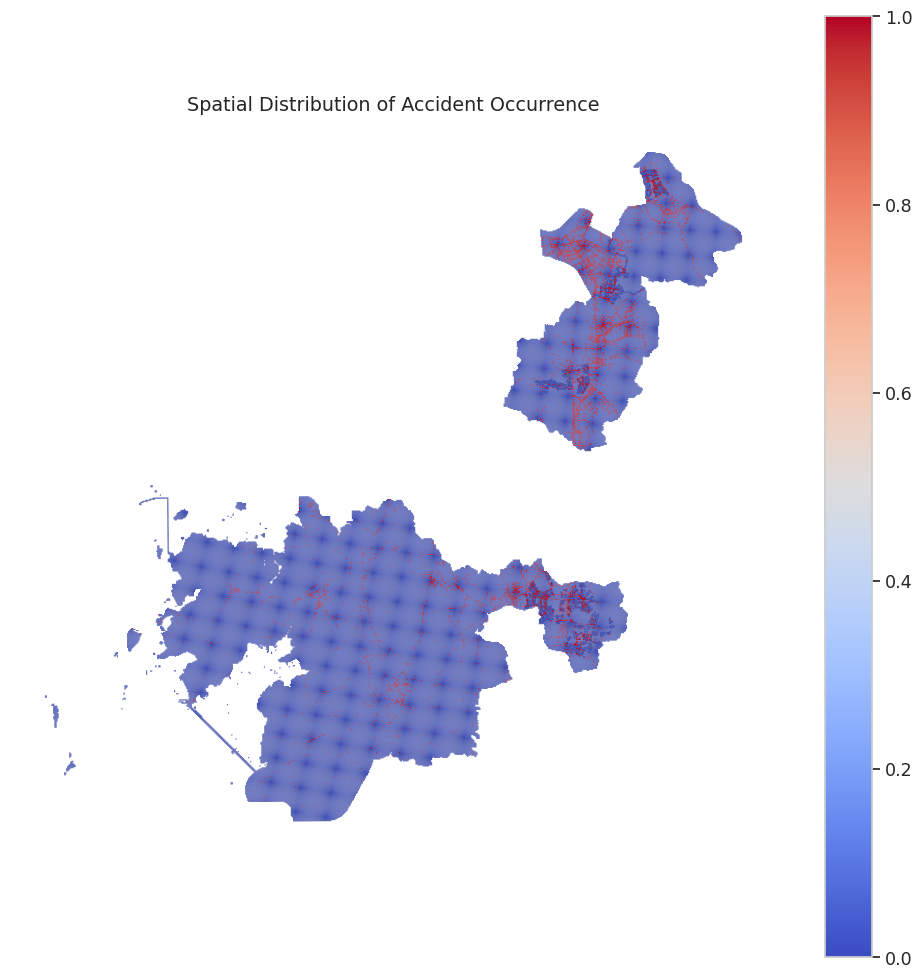

In [12]:
# 2) 사고 발생여부 지도
fig, ax = plt.subplots(figsize=(10, 10))

gdf.plot(
    column="acc_binary",
    cmap="coolwarm",
    linewidth=0.05,
    edgecolor="gray",
    legend=True,
    ax=ax
)

ax.set_title("Spatial Distribution of Accident Occurrence")
ax.axis("off")
plt.tight_layout()
plt.show()

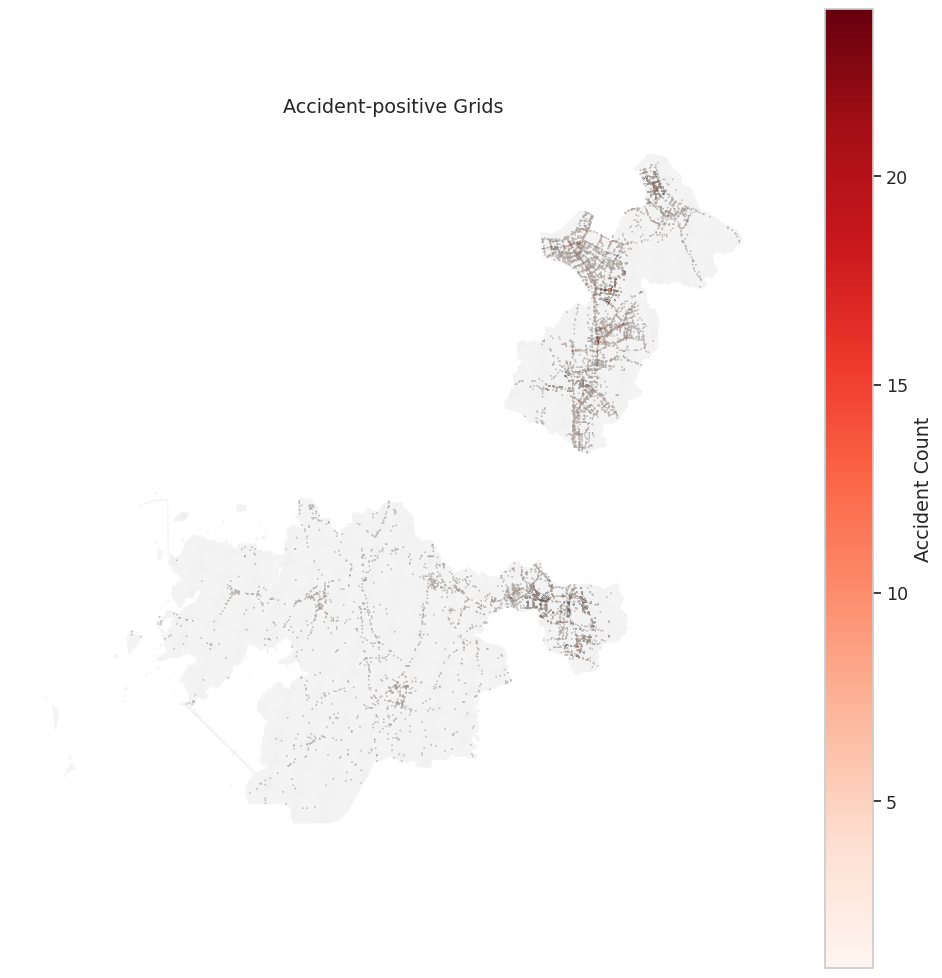

In [13]:
# 사고가 많은 격자만 따로 지도에 표시 

# 사고 발생 격자만 추출
gdf_acc = gdf[gdf["acc_cnt"] > 0].copy()

fig, ax = plt.subplots(figsize=(10, 10))

# 전체 격자 배경
gdf.plot(ax=ax, color="#F0F0F0", edgecolor="white", linewidth=0.05)

# 사고 발생 격자 강조
gdf_acc.plot(
    ax=ax,
    column="acc_cnt",
    cmap="Reds",
    edgecolor="black",
    linewidth=0.1,
    legend=True,
    legend_kwds={"label": "Accident Count"}
)

ax.set_title("Accident-positive Grids")
ax.axis("off")
plt.tight_layout()
plt.show()

In [14]:
# 사고 발생 격자 내부에서 상위 25%를 고사고 격자로 정의
acc_positive = gdf[gdf["acc_cnt"] > 0].copy()
high_threshold = acc_positive["acc_cnt"].quantile(0.75)

acc_positive["acc_level"] = np.where(
    acc_positive["acc_cnt"] >= high_threshold,
    "High Accident",
    "Lower Accident"
)

print("Threshold within accident-positive grids:", high_threshold)
print(acc_positive["acc_level"].value_counts())

Threshold within accident-positive grids: 2.0
acc_level
Lower Accident    4431
High Accident     2877
Name: count, dtype: int64


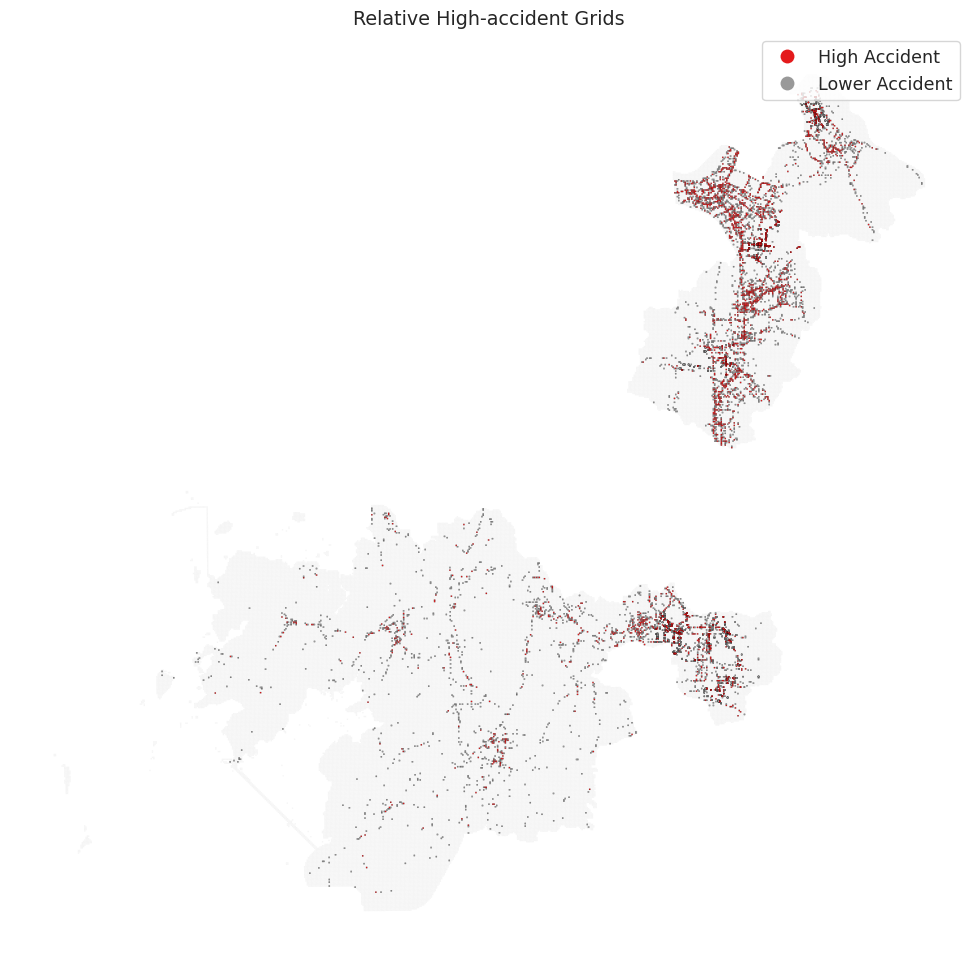

In [15]:
fig, ax = plt.subplots(figsize=(10, 10))

gdf.plot(ax=ax, color="#F5F5F5", edgecolor="white", linewidth=0.05)

acc_positive.plot(
    ax=ax,
    column="acc_level",
    categorical=True,
    legend=True,
    cmap="Set1",
    edgecolor="black",
    linewidth=0.1
)

ax.set_title("Relative High-accident Grids")
ax.axis("off")
plt.tight_layout()
plt.show()

사고 발생 격자 내부에서도 상대적으로 사고 건수가 높은 격자를 구분해 본 결과, 고사고 격자는 특정 지역에 모여 나타나는 경향을 보였다. 이는 사고가 단순히 발생 여부 차원에서만 구분되는 것이 아니라, 사고 강도 측면에서도 공간적 집중 가능성이 존재함을 시사한다.

In [16]:
# 거리 기반 분석을 위해 투영 좌표계로 변환
gdf_proj = gdf.to_crs(epsg=5186)

print(gdf_proj.crs)
gdf_proj.head()

EPSG:5186


,gid,city,geometry,acc_cnt,acc_binary,resident_pop,flow_pop,working_pop,visit_pop,service_pop,...,daycare_count,cctv_count,speedbump_count,blockType_main,landuse_group,is_residential,is_commercial,is_green,is_road,is_public
0,다사581304,경기도 성남시,"POLYGON ((202371.605 530267.414, 202371.075 53...",0,0,0.0,0.000000,0.000000,0.000000,0.0,...,0.0,0.0,0.0,unknown,other,0,0,0,0,0
1,다사581305,경기도 성남시,"POLYGON ((202371.075 530367.450, 202370.545 53...",0,0,0.0,0.031594,0.015572,0.016022,0.0,...,0.0,0.0,0.0,unknown,other,0,0,0,0,0
2,다사581306,경기도 성남시,"POLYGON ((202370.545 530467.486, 202370.015 53...",0,0,0.0,0.000000,0.000000,0.000000,0.0,...,0.0,0.0,0.0,unknown,other,0,0,0,0,0
3,다사582304,경기도 성남시,"POLYGON ((202471.642 530267.943, 202471.112 53...",0,0,0.0,0.022768,0.018269,0.004499,0.0,...,0.0,0.0,0.0,unknown,other,0,0,0,0,0
4,다사582305,경기도 성남시,"POLYGON ((202471.112 530367.980, 202470.582 53...",0,0,0.0,0.031655,0.016485,0.015169,0.0,...,0.0,0.0,0.0,unknown,other,0,0,0,0,0


In [17]:
# centroid 생성

gdf_proj["centroid"] = gdf_proj.geometry.centroid
gdf_proj["x"] = gdf_proj["centroid"].x
gdf_proj["y"] = gdf_proj["centroid"].y

gdf_proj[["gid", "city", "acc_cnt", "x", "y"]].head()

,gid,city,acc_cnt,x,y
0,다사581304,경기도 성남시,0,202421.358483,530317.696680
1,다사581305,경기도 성남시,0,202420.828573,530417.733141
2,다사581306,경기도 성남시,0,202420.298653,530517.769601
3,다사582304,경기도 성남시,0,202521.394949,530318.226584
4,다사582305,경기도 성남시,0,202520.865039,530418.263056


<Figure size 1000x1000 with 0 Axes>

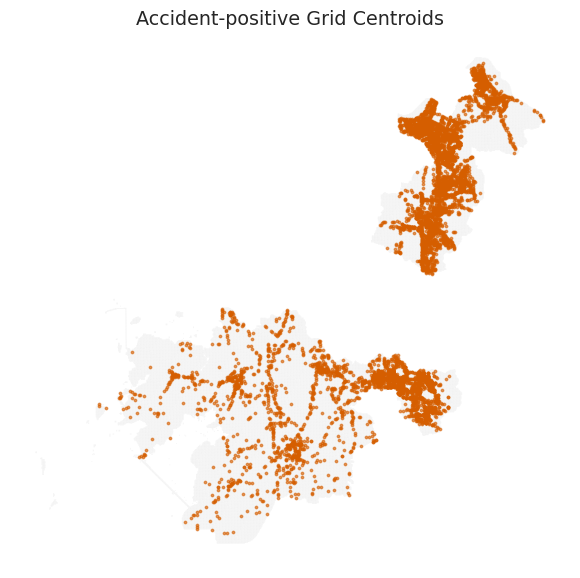

In [18]:
# 사고 발생 격자만 추출
acc_points = gdf_proj[gdf_proj["acc_cnt"] > 0].copy()

plt.figure(figsize=(10, 10))

# 전체 grid 배경
gdf_proj.plot(color="#F2F2F2", edgecolor="white", linewidth=0.05)

# 사고 centroid 표시
plt.scatter(
    acc_points["x"],
    acc_points["y"],
    s=3,
    c="#D55E00",
    alpha=0.6
)

plt.title("Accident-positive Grid Centroids")
plt.axis("off")
plt.tight_layout()
plt.show()

## 사고 발생 격자의 중심점 분포

사고 발생 격자의 중심점을 시각화한 결과, 사고는 개별 격자에 산발적으로 나타나는 것이 아니라 특정 도로축과 생활권 주변에 밀집되는 경향을 보였다.

- 이는 교통사고가 공간적으로 무작위하게 발생하는 현상이라기보다, 특정 도시 구조와 이동 패턴에 따라 집중적으로 나타날 가능성이 있음을 보여준다.

<Figure size 1000x1000 with 0 Axes>

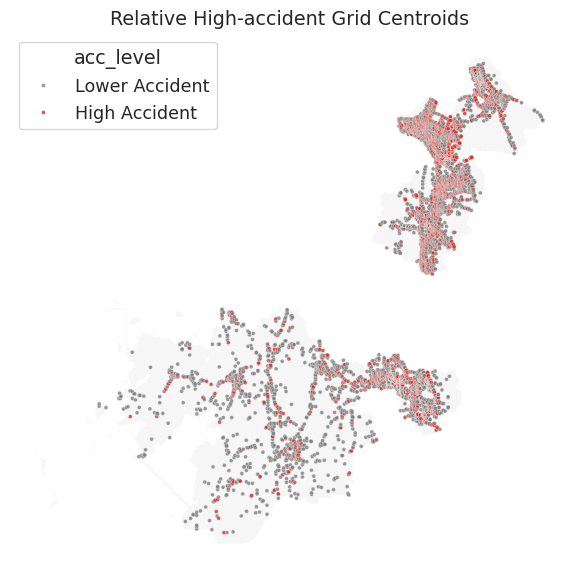

In [19]:
# 고사고 / 저사고 격자 centroid 분리
high_acc_points = acc_positive.to_crs(epsg=5186).copy()
high_acc_points["centroid"] = high_acc_points.geometry.centroid
high_acc_points["x"] = high_acc_points["centroid"].x
high_acc_points["y"] = high_acc_points["centroid"].y

plt.figure(figsize=(10, 10))

gdf_proj.plot(color="#F5F5F5", edgecolor="white", linewidth=0.05)

sns.scatterplot(
    data=high_acc_points,
    x="x",
    y="y",
    hue="acc_level",
    palette={"High Accident": "#D73027", "Lower Accident": "#7F7F7F"},
    s=8,
    alpha=0.8
)

plt.title("Relative High-accident Grid Centroids")
plt.axis("off")
plt.tight_layout()
plt.show()

사고 발생 격자 내부에서 상대적으로 사고 건수가 높은 격자를 구분해 본 결과, 고사고 격자는 도시 내 특정 축과 생활권 주변에 더욱 밀집되어 나타났다.

- 이는 사고 발생 여부뿐 아니라 사고 강도 측면에서도 공간적 집중 가능성이 존재함을 시사한다.

<Figure size 1000x1000 with 0 Axes>

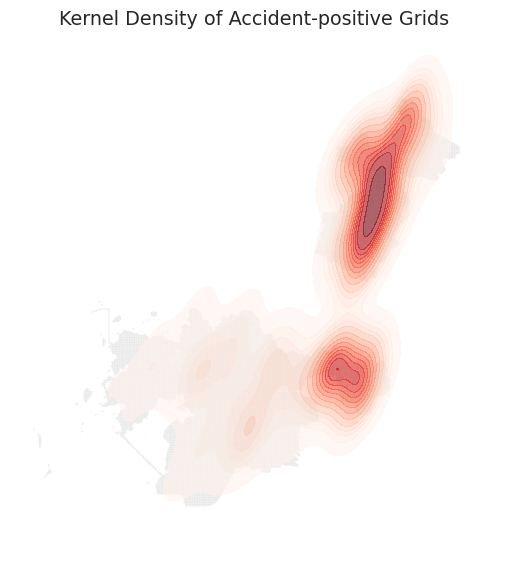

In [20]:
## KDE 형태 밀집도 시각화

plt.figure(figsize=(10, 10))

# 전체 영역 배경
gdf_proj.plot(color="#FAFAFA", edgecolor="lightgray", linewidth=0.05)

# 사고 centroid KDE
sns.kdeplot(
    data=acc_points,
    x="x",
    y="y",
    fill=True,
    cmap="Reds",
    levels=15,
    thresh=0.02,
    alpha=0.6
)

plt.title("Kernel Density of Accident-positive Grids")
plt.axis("off")
plt.tight_layout()
plt.show()

<Figure size 1000x1000 with 0 Axes>

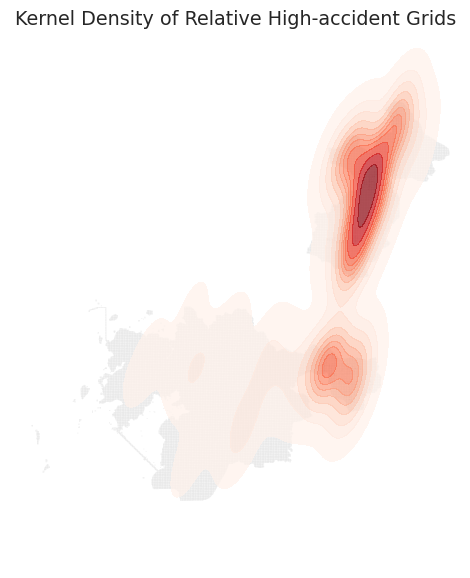

In [21]:
# 고사고 격자 KDE
high_only = high_acc_points[high_acc_points["acc_level"] == "High Accident"].copy()

plt.figure(figsize=(10, 10))

gdf_proj.plot(color="#FAFAFA", edgecolor="lightgray", linewidth=0.05)

sns.kdeplot(
    data=high_only,
    x="x",
    y="y",
    fill=True,
    cmap="Reds",
    levels=12,
    thresh=0.01,
    alpha=0.7
)

plt.title("Kernel Density of Relative High-accident Grids")
plt.axis("off")
plt.tight_layout()
plt.show()

## 사고 격자의 밀집 패턴

사고 발생 격자 및 고사고 격자의 밀집도를 시각화한 결과, 사고는 특정 도로축과 생활권 주변에서 높은 밀도로 나타났다. 특히 상대적 고사고 격자는 단순히 사고가 발생한 모든 지역에 균등하게 퍼져 있는 것이 아니라, 일부 권역에 더욱 집중되는 양상을 보였다. 이는 사고 위험이 특정 도시 구조와 반복적으로 연결될 가능성을 보여준다.

In [22]:
from sklearn.cluster import DBSCAN

In [23]:
# 고사고 격자만 대상으로 클러스터링

# High Accident 격자만 사용
high_only = high_acc_points[high_acc_points["acc_level"] == "High Accident"].copy()

coords = high_only[["x", "y"]].values

# eps는 거리 임계값(미터 단위), min_samples는 최소 포인트 수
dbscan = DBSCAN(eps=300, min_samples=10)
high_only["cluster"] = dbscan.fit_predict(coords)

high_only["cluster"].value_counts().sort_index()

cluster
-1     1430
 0       10
 1       13
 2       10
 3       10
 4       61
 5       20
 6       14
 7       24
 8       38
 9       22
 10      64
 11      31
 12     116
 13      37
 14       7
 15      40
 16      38
 17      48
 18      19
 19      11
 20      13
 21     110
 22      13
 23      28
 24      10
 25      24
 26      10
 27      97
 28      11
 29      60
 30      23
 31      11
 32      42
 33       6
 34      17
 35      10
 36      42
 37      20
 38      18
 39      11
 40      23
 41      10
 42      12
 43      22
 44      21
 45      30
 46      85
 47      15
 48      10
 49      10
Name: count, dtype: int64

<Figure size 1000x1000 with 0 Axes>

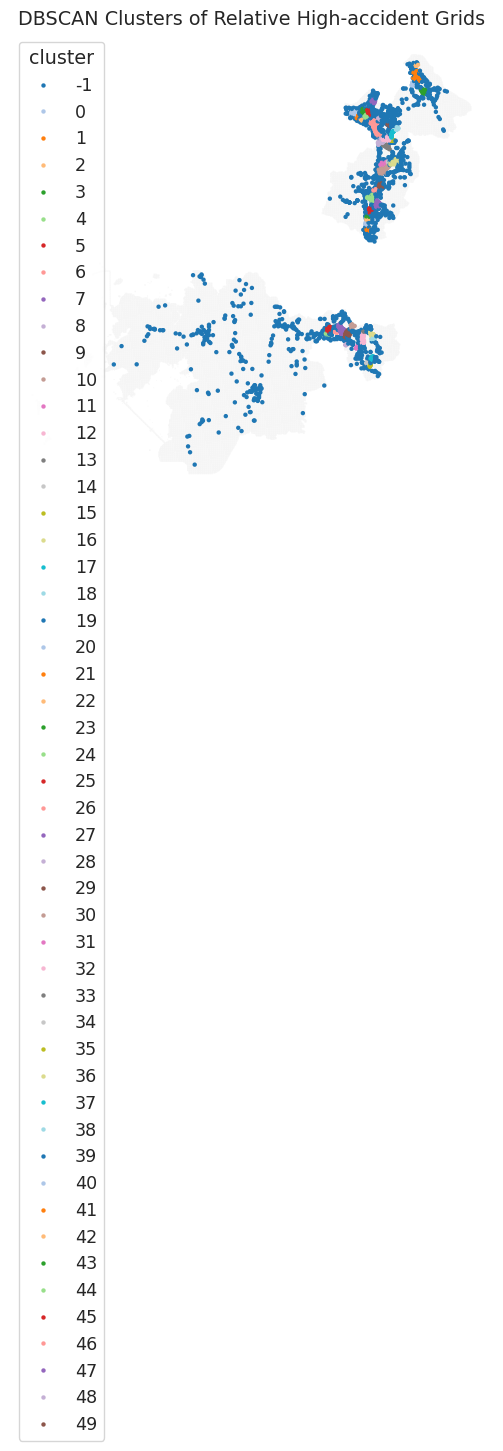

In [24]:
# 클러스터 지도 시각화
plt.figure(figsize=(10, 10))

gdf_proj.plot(color="#F5F5F5", edgecolor="white", linewidth=0.05)

sns.scatterplot(
    data=high_only,
    x="x",
    y="y",
    hue="cluster",
    palette="tab20",
    s=10,
    linewidth=0
)

plt.title("DBSCAN Clusters of Relative High-accident Grids")
plt.axis("off")
plt.tight_layout()
plt.show()

In [25]:
# 노이즈 제외 클러스터 개수 확인하기

cluster_counts = high_only["cluster"].value_counts().sort_index()
cluster_counts

valid_clusters = high_only[high_only["cluster"] != -1].copy()
print("Number of clustered grids:", len(valid_clusters))
print("Number of noise grids:", (high_only["cluster"] == -1).sum())
print("Number of detected clusters:", valid_clusters["cluster"].nunique())

Number of clustered grids: 1447
Number of noise grids: 1430
Number of detected clusters: 50


In [26]:
# 클러스터 요약

cluster_summary = (
    valid_clusters.groupby("cluster")
    .agg(
        grid_count=("gid", "count"),
        mean_acc=("acc_cnt", "mean"),
        max_acc=("acc_cnt", "max"),
        city_mode=("city", lambda x: x.mode().iloc[0] if len(x.mode()) > 0 else x.iloc[0])
    )
    .sort_values("grid_count", ascending=False)
    .reset_index()
)

cluster_summary.head(10)

,cluster,grid_count,mean_acc,max_acc,city_mode
0,12,116,5.474138,14,서울특별시 송파구
1,21,110,4.081818,10,경기도 하남시
2,27,97,2.783505,11,경기도 화성시
3,46,85,3.823529,14,서울특별시 송파구
4,10,64,5.343750,24,경기도 성남시
5,4,61,3.147541,12,경기도 성남시
6,29,60,4.266667,15,경기도 화성시
7,17,48,3.500000,8,경기도 하남시
8,36,42,2.952381,7,경기도 화성시
9,32,42,3.428571,6,경기도 화성시


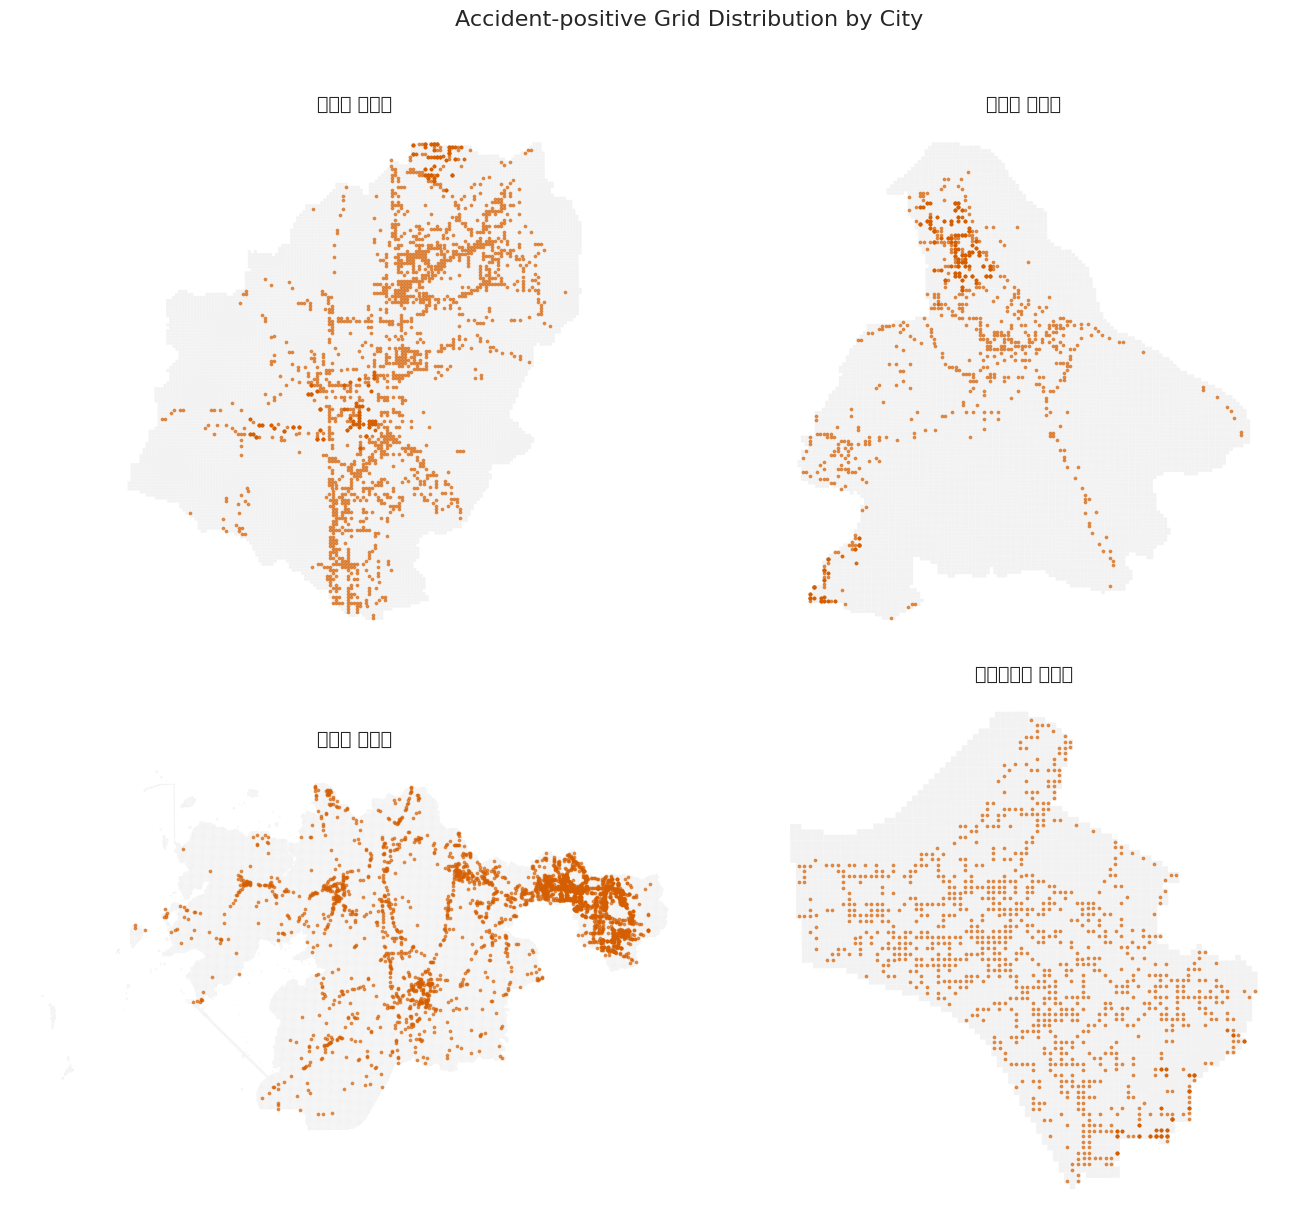

In [27]:
# 도시별로 나눠서 보기

cities = gdf_proj["city"].unique()

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

for i, city in enumerate(cities):
    city_bg = gdf_proj[gdf_proj["city"] == city]
    city_acc = acc_points[acc_points["city"] == city]

    city_bg.plot(ax=axes[i], color="#F2F2F2", edgecolor="white", linewidth=0.05)
    axes[i].scatter(city_acc["x"], city_acc["y"], s=3, c="#D55E00", alpha=0.6)
    axes[i].set_title(city)
    axes[i].axis("off")

# 남는 축 제거
for j in range(len(cities), len(axes)):
    fig.delaxes(axes[j])

fig.suptitle("Accident-positive Grid Distribution by City", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

## DBSCAN 기반 사고 집중 권역 탐색

정식 hotspot 통계 대신, 상대적 고사고 격자의 중심점을 대상으로 밀도 기반 클러스터링(DBSCAN)을 수행한 결과, 여러 개의 사고 집중 권역이 탐지되었다.

이는 고사고 격자가 도시 전역에 균등하게 퍼져 있는 것이 아니라, 특정 구간과 생활권 주변에서 군집 형태로 분포함을 보여준다.

따라서 사고는 개별 격자의 우연한 사건이라기보다, 특정 공간 구조와 교통 환경이 결합된 권역 단위 현상으로 해석할 수 있다.

- 도시별로 사고 발생 격자를 나누어 시각화한 결과, 각 도시 내에서도 사고가 특정 생활권과 도로축을 따라 집중되는 패턴이 반복적으로 나타났다.

이는 사고 집중 현상이 특정 한 도시의 예외적 특성이 아니라, 신도시 전반에서 공통적으로 나타날 수 있는 구조적 현상일 가능성을 보여준다.

In [28]:
# DBSCAN 결과를 원본 high_only에 반영 후 저장

save_high = high_only.copy()

save_high.drop(columns=["centroid"]).to_csv(
    "../outputs/processed/04_high_accident_dbscan_result.csv",
    index=False
)

gdf_proj.drop(columns=["centroid"]).to_file(
    "../outputs/processed/04_spatial_base.geojson",
    driver="GeoJSON"
)

print("Saved spatial outputs.")

Saved spatial outputs.


## 사고 집중 권역 분석

고사고 격자(상위 25%)의 중심점을 대상으로 DBSCAN 기반 밀도 클러스터링을 수행한 결과,
총 50개의 사고 집중 권역(cluster)이 탐지되었다.

특히 고사고 격자의 약 절반 이상이 클러스터 형태로 묶이며,
사고가 개별 격자 단위의 우연한 사건이라기보다
특정 공간 권역에서 군집 형태로 발생하는 경향을 보였다.

주요 사고 집중 권역은 다음과 같은 지역에서 나타났다.

- 서울 송파구 일대 (위례신도시 인접 지역)
- 경기도 하남시 (하남 미사)
- 경기도 화성시 (동탄신도시)
- 경기도 성남시 (판교 일대)

이는 교통사고가 단순히 특정 지점에서 발생하는 것이 아니라,
신도시의 주요 생활권과 교통 축 주변에서 집중적으로 나타날 가능성을 보여준다.

<Figure size 1000x1000 with 0 Axes>

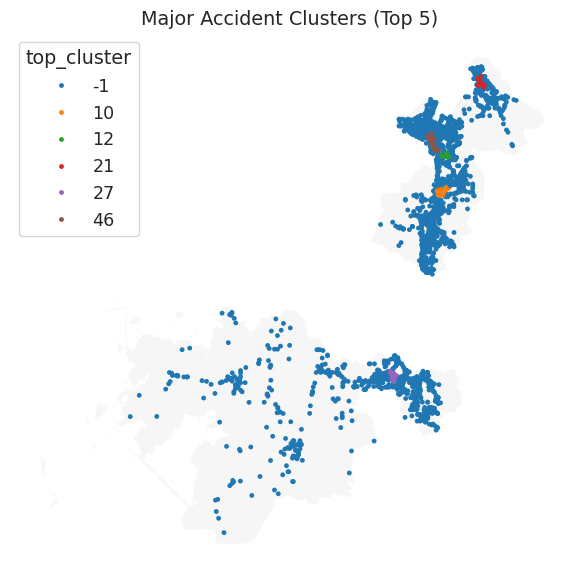

In [31]:
top_clusters = cluster_summary.head(5)["cluster"].tolist()

high_only["top_cluster"] = high_only["cluster"].apply(
    lambda x: x if x in top_clusters else -1
)

plt.figure(figsize=(10,10))

gdf_proj.plot(color="#F5F5F5", edgecolor="white", linewidth=0.05)

sns.scatterplot(
    data=high_only,
    x="x",
    y="y",
    hue="top_cluster",
    palette="tab10",
    s=12,
    linewidth=0
)

plt.title("Major Accident Clusters (Top 5)")
plt.axis("off")
plt.tight_layout()
plt.show()

## 공간 분석 종합 결과

격자 단위 교통사고 데이터를 공간적으로 분석한 결과,
교통사고는 도시 전반에 균등하게 분포하지 않고
특정 지역에서 집중되는 경향을 보였다.

사고 발생 격자 내부에서도 상대적으로 사고 건수가 높은 격자는
일부 생활권 주변에서 더욱 밀집되는 패턴이 나타났다.

DBSCAN 기반 밀도 클러스터링 분석 결과,
총 50개의 사고 집중 권역이 탐지되었으며
고사고 격자의 절반 이상이 이러한 클러스터에 포함되었다.

특히 송파, 하남, 성남, 화성 등 주요 신도시 생활권에서
사고 집중 권역이 반복적으로 나타났으며,
이는 교통사고가 도시 구조 및 교통 흐름과 밀접하게 연결된
공간적 현상임을 보여준다.